# Blind source separation
Blind Source Separation (BSS) is a challenging problem in signal processing where the goal is to recover original source signals from observed mixed data without prior knowledge of the mixing process. In this project, we tackle BSS for images by designing a deep learning model to separate mixed MNIST digits and Fashion MNIST images. The mixed input is a pixel-wise summation of two images (one from each dataset), and the model aims to reconstruct the two original sources.

To address this, we implement a `U-Net-based architecture`, a proven framework for tasks requiring spatial understanding, such as image segmentation and reconstruction. We have also implemented a traditional Auto Encoder Decoder which proves to be a good architecture, but not the best.







For this project:
- No preprocessing is allowed. The neural network receives the combined image (img1 + img2) as input and outputs the predicted components (hat_img1, hat_img2).
- Performance is evaluated using the mean squared error (MSE) between the predicted and ground-truth images.
- Both datasets (MNIST and Fashion-MNIST) are grayscale. For simplicity, all samples are padded to a (32, 32) resolution.

# Outlines
- [Packages](#Packages)
- [Data](#data)
- [Architectures](#architecture)
    - [U-Net Architecture](#unet)
    - [AutoEncoderDecoder Architecture](#autoencodedecode)
- [Model Training](#training)
- [Model Evaluation](#evaluation)




<a name='Packages'></a>
# Packages
Importing packages and making connections.

In [2]:
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras import layers, Sequential, Model
from sklearn.model_selection import ParameterGrid
from tensorflow.keras.layers import *
import tensorflow as tf
import keras

from matplotlib import pyplot as plt
import numpy as np

<a name='data'></a>
# Data
Importing Data from the datasets and using datagenerator to create the input data.

In [3]:
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(fashion_mnist_x_train, fashion_mnist_y_train), (fashion_mnist_x_test, fashion_mnist_y_test) = fashion_mnist.load_data()

# Normalization and Padding
mnist_x_train = np.pad(mnist_x_train,((0,0),(2,2),(2,2)))/255.
mnist_x_test = np.pad(mnist_x_test,((0,0),(2,2),(2,2)))/255.

fashion_mnist_x_train = np.pad(fashion_mnist_x_train,((0,0),(2,2),(2,2)))/255.
fashion_mnist_x_test = np.pad(fashion_mnist_x_test,((0,0),(2,2),(2,2)))/255.

print("fashion_mnist_x_train shape:", np.shape(fashion_mnist_x_train))
print("fashion_mnist_x_test shape:", np.shape(fashion_mnist_x_test), '\n')
print("mnist_x_train shape:", np.shape(mnist_x_train))
print("mnist_x_test shape:", np.shape(mnist_x_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
fashion_mnist_x_train shape: (60000, 32, 32)
fashion_mnist_x_test shape: (10000, 32, 32) 

mnist_x_train shape: (60000, 32, 32)
mnist_x_test shape: (10000, 32, 32)


Data Generator of this problem is as follow:

In [4]:
def datagenerator(x1, x2, batchsize):
    n1 = x1.shape[0]
    n2 = x2.shape[0]
    while True:
        num1 = np.random.randint(0, n1, batchsize)
        num2 = np.random.randint(0, n2, batchsize)

        x_data = (x1[num1] + x2[num2]) / 2.0
        y_data = (x1[num1], x2[num2])

        yield x_data, y_data

The following method can be used for showing the images.

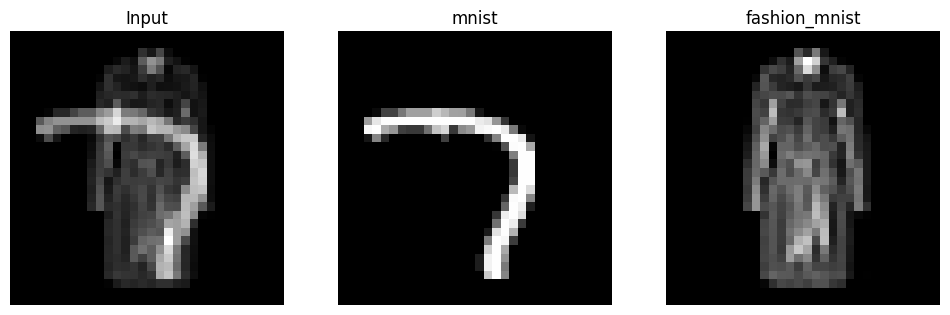

In [5]:
def show_images(x,y1,y2):
    fig, ax = plt.subplots(1,3,figsize=(12,4))
    ax[0].imshow(x,cmap='gray')
    ax[0].title.set_text('Input')
    ax[0].axis('off')
    ax[1].imshow(y1,cmap='gray')
    ax[1].title.set_text('mnist')
    ax[1].axis('off')
    ax[2].imshow(y2,cmap='gray')
    ax[2].title.set_text('fashion_mnist')
    ax[2].axis('off')
    plt.show()

# Choosing an image with generator
onegen = datagenerator(mnist_x_test, fashion_mnist_x_test, 1)
x, (y1, y2) = next(onegen)
show_images(x[0], y1[0], y2[0])

<a name='architecture'></a>
# Architectures
In this section we will implement the main architectures that we will use for training our model on the input data.

Our architecutures, both of them, are first encoding the image into a representation, then the representation is passed to the decoder for the generation of the two images.

<a name='unet'></a>
## U-Net Architecture
Our first proposed model is based on a U-Net with symmetric encoder-decoder blocks, skip connections, and dual output heads for the generation of the two images.

Our big scale view:
- `Encoder` extracts hierarchical features from the input image through downsampling.
- `Decoder` in continue to the encoder, is responsible for reconstructing the source images by upsampling and leveraging skip connections from the encoder.
- These `Skip Connections` bridge the layers and help us in preserving some information from previous layers.


Our hyperparameters and their default is as follow:
- `Base Channels`: Initial filter count (n_channel=128), doubled after each encoder block.
- `Blocks`: Number of encoder/decoder blocks (n_blocks=4)
- `Convolutions per Block`: Convolutional layers per block (conv_per_block=3)

#### Encoder Block
In the `_encoder_block()` method for each block we have defined `conv_per_b` `Conv2D` layers along with `BatchNormalization` and `ReLU` activation. After that, Until the last block we have saved the feature representation of each block (for decoder) and then with `MaxPooling2D()` we have downsampled. Moreover, we have doubled the number of channels after each block.



#### Decoder Block
In the `_decoder_block()` method for each block we have applied `Upsampling` first by dividing the number of channels by the same factor `2` and transposed convolution.

Then, we used the skip connections that we defined in the encoder step, concatenate the value of corresponding encoder with the current feature map in the decoder. At the end we post upsampled the features.


#### Outputs Heads
After the encoding and the decoding step, we have defined another method `build_model()` which builds the architecture for us and after building the encoder and the decoder blocks, it adds two more layers to the network, the `out1` and `out2` which returns the outputs prediction for the images.

In [6]:
class UNet(tf.keras.Model):
    def __init__(self, input_shape):
        super(UNet, self).__init__()
        self.input_shape = input_shape


        self.model = None
        self.history = None

    def _encoder_block(self, inputs, id_layer, n_blocks, n_ch, conv_per_b, backup_layers, decoder=False):
        feature_map = inputs
        for i in range(conv_per_b):
            feature_map = Conv2D(n_ch, 3, 1, padding='same')(feature_map)
            feature_map = BatchNormalization()(feature_map)
            feature_map = ReLU()(feature_map)

        if not decoder and id_layer < n_blocks - 1:
            backup_layers.append(feature_map)
            feature_map = MaxPooling2D(padding='same')(feature_map)
            n_ch = n_ch * 2

        return feature_map, n_ch


    def _decoder_block(self, inputs, id_layer, n_blocks, n_ch, conv_per_b, backup_layers):
        n_ch = n_ch // 2
        feature_map = Conv2DTranspose(n_ch, 3, 2, padding='same')(inputs)
        feature_map = concatenate([feature_map, backup_layers.pop()])
        feature_map, n_ch = self._encoder_block(feature_map, id_layer, n_blocks, n_ch, conv_per_b, backup_layers, decoder=True)

        return feature_map, n_ch


    def build_model(self, n_ch=32, blocks=4, conv_per_b=2):
        x = Input(shape=self.input_shape)
        backup_layers = []
        feature_map = x

        # Encoder part
        for b in range(blocks):
            feature_map, n_ch = self._encoder_block(feature_map, b, blocks, n_ch, conv_per_b, backup_layers, decoder=False)

        # Decoder part
        for b in range(blocks - 1):
            feature_map, n_ch = self._decoder_block(feature_map, b, blocks, n_ch, conv_per_b, backup_layers)

        # Output
        out1 = Conv2D(1, 1, activation='sigmoid', name="out1")(feature_map)
        out2 = Conv2D(1, 1, activation='sigmoid', name="out2")(feature_map)
        self.model = Model(x, outputs=[out1, out2])

        return self.model


    def compile(self, optimizer='adam', loss='mse'):
        self.model.compile(optimizer=optimizer, loss=loss)


    def train(self, train_data, epochs=20, steps_per_epoch=1000):
        self.history = self.model.fit(train_data, epochs=epochs, steps_per_epoch=steps_per_epoch)
        return self.history


    def eval_model(self, test_data):
        # The whole data that could be separated as follow
        x, (y1, y2) = next(test_data)

        # Predicting test data
        pred1, pred2 = self.model.predict(x)

        pred1 = pred1.squeeze()
        pred2 = pred2.squeeze()

        return (np.mean((pred1-y1)**2) + np.mean((pred2-y2)**2) / 2)


    def show_sample_prediction(self, test_gen, n_sample=2):
        '''
            Input: Takes the test generator that returns only one data.
            Output: Shows the prediction and real image of that test data
        '''

        def show_images(x, y1, y2):
            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(x, cmap='gray')
            ax[0].title.set_text('Input')
            ax[0].axis('off')

            ax[1].imshow(y1, cmap='gray')
            ax[1].title.set_text('mnist')
            ax[1].axis('off')

            ax[2].imshow(y2, cmap='gray')
            ax[2].title.set_text('fashion_mnist')
            ax[2].axis('off')

            plt.show()

        for n_s in range(n_sample):
            x, (y1, y2) = next(test_gen)

            # Show original images
            show_images(x[0], y1[0], y2[0])

            # Make predictions
            pred1, pred2 = self.model.predict(x)

            # Display predicted images
            show_images(x[0], pred1[0], pred2[0])


    def show_loss_epoch(self):
        plt.plot(self.history.history['loss'])
        plt.title('MSE Loss over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.show()


For training the U-Net we have also used parameter grid strategy to find the best parameters. The epochs number for tuning is set to 5 to keep it simple and faster.

In [7]:
def find_best_param(param_grid, epochs=5):
    best_params = None
    best_loss = float('inf')

    for params in ParameterGrid(param_grid):
        print(f"Training with parameters: {params}")

        model = UNet(input_shape=(32, 32, 1))
        model.build_model(n_ch=params['n_channel'], blocks=params['n_blocks'], conv_per_b=params['conv_per_block'])
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']), loss='mse')

        #Data generator for this specific experiment
        train_generator = datagenerator(mnist_x_train, fashion_mnist_x_train, params['batch_size'])

        history = model.train(train_generator, epochs=epochs, steps_per_epoch=100)

        # Evaluate the model (replace with your actual evaluation method)
        test_generator = datagenerator(mnist_x_test, fashion_mnist_x_test, params['batch_size'])
        loss = model.eval_model(test_generator)

        print(f"Validation loss: {loss}")
        if loss < best_loss:
            best_loss = loss
            best_params = params

    return best_params, best_loss

<a name='autoencodedecode'></a>
## Auto Encoder and Decoder
For our second architecture we have implemented an Autoencoder-Decoder model. Unlike the U-Net, which leverages skip connections and hierarchical feature fusion, this architecture adopts a traditional encoder-decoder structure with dual output branches to separate mixed MNIST and Fashion MNIST images.

In a general view, the model compresses the input into a latent representation and reconstructs the two sources independently.

#### Encoder
Similar to the way UNet is structured, here the encoder downsamples the input through three convolutional blocks:
- Convolution: Conv2D layers with ReLU activation and same padding.
- Downsampling: Max-pooling after each block to halve spatial dimensions.
- Latent Representation: Final features are flattened into a 1D vector.



#### Decoder
Each decoder branch, on the other hand, reconstructs a source image:
- Latent Expansion: A dense layer reshapes the latent vector into 8×8×128.
- Upsampling: Two Conv2DTranspose layers with stride 2 to restore spatial resolution.
- Output Layer: A final transposed convolution produces the reconstructed image.

The output is applied twice as we have two images to generate


In [8]:
class AutoEncoderDecoder(tf.keras.Model):
    def __init__(self, input_shape):
        super(AutoEncoderDecoder, self).__init__()
        self.input_shape = input_shape
        self.inputs = Input(shape=self.input_shape)

        self.model = None
        self.history = None
        self.encoder_out = None


    def _encoder(self):
        x = Conv2D(32, 3, activation='relu', padding='same')(self.inputs)
        x = MaxPooling2D()(x)
        x = Conv2D(64, 3, activation='relu', padding='same')(x)
        x = MaxPooling2D()(x)
        x = Conv2D(128, 3, activation='relu', padding='same')(x)
        x = Flatten()(x)
        self.encoder_out = x

        return self.encoder_out


    def _decoder(self):
        # Decoding image 1
        x1 = Dense(128 * 8 * 8, activation='relu')(self.encoder_out)
        x1 = Reshape((8, 8, 128))(x1)
        x1 = Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x1)
        x1 = Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x1)
        output1 = Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x1)

        # Decoding image 2
        x2 = Dense(128 * 8 * 8, activation='relu')(self.encoder_out)
        x2 = Reshape((8, 8, 128))(x2)
        x2 = Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x2)
        x2 = Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x2)
        output2 = Conv2DTranspose(1, 3, padding='same', activation='sigmoid')(x2)

        self.model = keras.Model(inputs=self.inputs, outputs=[output1, output2])
        return self.model


    def build_mode(self):
        self._encoder()
        model = self._decoder()

        return model


    def compile(self, optimizer='adam', loss='mse'):
        self.model.compile(optimizer=optimizer, loss=loss)


    def train(self, train_data, epochs=20, steps_per_epoch=1000):
        self.history = self.model.fit(train_data, epochs=epochs, steps_per_epoch=steps_per_epoch)
        return self.history


    def eval_model(self, test_data):
        # The whole data that could be separated as follow
        x, (y1, y2) = next(test_data)

        # Predicting test data
        pred1, pred2 = self.model.predict(x)

        pred1 = pred1.squeeze()
        pred2 = pred2.squeeze()

        return (np.mean((pred1-y1)**2) + np.mean((pred2-y2)**2) / 2)


    def show_sample_prediction(self, test_gen, n_sample=2):
        '''
            Input: Takes the test generator that returns only one data.
            Output: Shows the prediction and real image of that test data
        '''

        def show_images(x, y1, y2):
            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(x,cmap='gray')
            ax[0].title.set_text('Input')
            ax[0].axis('off')

            ax[1].imshow(y1,cmap='gray')
            ax[1].title.set_text('mnist')
            ax[1].axis('off')

            ax[2].imshow(y2,cmap='gray')
            ax[2].title.set_text('fashion_mnist')
            ax[2].axis('off')

            plt.show()

        for n_s in range(n_sample):
            x, (y1, y2) = next(test_gen)

            # Show original images
            show_images(x[0], y1[0], y2[0])

            # Make predictions
            pred1, pred2 = self.model.predict(x)

            # Display predicted images
            show_images(x[0], pred1[0], pred2[0])


    def show_loss_epoch(self):
        plt.plot(self.history.history['loss'])
        plt.title('MSE Loss over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.show()


Similar to the one we have for the UNet, we defined the following function to find the best learning rate and the batch size.

In [9]:
# Function to perform hyperparameter tuning for the AutoEncoderDecoder model
def find_best_param_autoencoder(param_grid, epochs=5):
    best_params = None
    best_loss = float('inf')

    for params in ParameterGrid(param_grid):
        print(f"Training with parameters: {params}")

        model = AutoEncoderDecoder(input_shape=(32, 32, 1))
        model.build_mode()  # Build the model
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=params['learning_rate']), loss='mse')

        train_generator = datagenerator(mnist_x_train, fashion_mnist_x_train, params['batch_size'])
        history = model.train(train_generator, epochs=epochs, steps_per_epoch=100)

        test_generator = datagenerator(mnist_x_test, fashion_mnist_x_test, params['batch_size'])
        loss = model.eval_model(test_generator)

        print(f"Validation loss: {loss}")
        if loss < best_loss:
            best_loss = loss
            best_params = params

    return best_params, best_loss

<a name='training'></a>
# Models Training

Let's first set the parameters and generate the data:

In [10]:
batch_size = 128
epochs = 50

train_generator = datagenerator(mnist_x_train, fashion_mnist_x_train, batch_size)

steps_per_epoch = len(mnist_x_train) // batch_size

In the next two cell we will work on the UNet architecture. We first using the parameter tuning function, find the best parameter for the network, then we will use those parameters to train the model more and report the outputs.

Training with parameters: {'batch_size': 128, 'conv_per_block': 3, 'learning_rate': 0.001, 'n_blocks': 3, 'n_channel': 32}
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.1528 - out1_loss: 0.1013 - out2_loss: 0.0516
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0176 - out1_loss: 0.0102 - out2_loss: 0.0073
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0098 - out1_loss: 0.0055 - out2_loss: 0.0043
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0075 - out1_loss: 0.0040 - out2_loss: 0.0035
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0058 - out1_loss: 0.0031 - out2_loss: 0.0028
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Validation loss: 0.028398658568631586
Training with parameters: {'batch_size': 128, 'conv_per_block': 3, 'learning_rate': 0.001, 'n_blocks': 3, 'n_channel': 64}
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.1067 - out1_loss: 0.0681 - out2_loss: 0.0385
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━

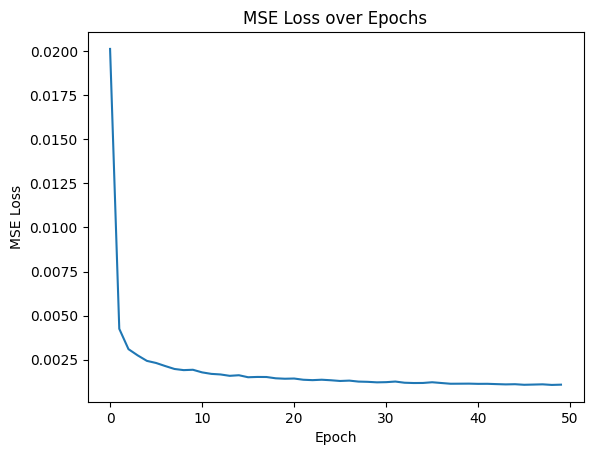

In [11]:
# Hyperparameter tuning for UNet
param_grid = {
    'learning_rate': [0.001, 1e-4],
    'batch_size': [128],
    'n_blocks': [3, 4, 6],
    'n_channel': [32, 64],
    'conv_per_block': [3, 4]
}

best_params, best_loss = find_best_param(param_grid)

print(f"Best parameters: {best_params} with loss: {best_loss}")

# Train the final model with the best hyperparameters
UNet_best_model = UNet(input_shape=(32, 32, 1))
UNet_best_model.build_model(n_ch=best_params['n_channel'], blocks=best_params['n_blocks'], conv_per_b=best_params['conv_per_block'])
UNet_best_model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']), loss='mse')

train_generator = datagenerator(mnist_x_train, fashion_mnist_x_train, best_params['batch_size'])
UNet_history = UNet_best_model.train(train_generator, epochs=epochs, steps_per_epoch=steps_per_epoch)
UNet_best_model.show_loss_epoch()
# print(UNet_model.summary())

Similarly, find the best learning rate and batchsize for the AutoEncoderDecoder and train the model with those.

Training with parameters: {'batch_size': 32, 'learning_rate': 0.001}
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - conv2d_transpose_87_loss: 0.1033 - conv2d_transpose_90_loss: 0.0993 - loss: 0.2026
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_87_loss: 0.0406 - conv2d_transpose_90_loss: 0.0277 - loss: 0.0683
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_87_loss: 0.0223 - conv2d_transpose_90_loss: 0.0196 - loss: 0.0418
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_87_loss: 0.0164 - conv2d_transpose_90_loss: 0.0170 - loss: 0.0335
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_87_loss: 0.0137 - conv2d_transpose_90_loss: 0.0150 - loss: 0.0286
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
Validation loss: 0.019740697467619524
Training with parameters: {'batch_size': 32, 'learning_rate': 0.0001}
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - conv2d_transpose_93_loss: 0.1660 - conv2d_transpose

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
Validation loss: 0.04239924495392713
Training with parameters: {'batch_size': 64, 'learning_rate': 0.001}
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - conv2d_transpose_102_loss: 0.0959 - conv2d_transpose_99_loss: 0.1071 - loss: 0.2030
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_102_loss: 0.0260 - conv2d_transpose_99_loss: 0.0409 - loss: 0.0669
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_102_loss: 0.0192 - conv2d_transpose_99_loss: 0.0216 - loss: 0.0408
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_102_loss: 0.0156 - conv2d_transpose_99_loss: 0.0155 - loss: 0.0311
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_102_loss: 0.0138 - conv2d_transpose_99_loss: 0.0125 - loss: 0.0264


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
Validation loss: 0.018147738202496495
Training with parameters: {'batch_size': 64, 'learning_rate': 0.0001}
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - conv2d_transpose_105_loss: 0.1695 - conv2d_transpose_108_loss: 0.1532 - loss: 0.3227
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - conv2d_transpose_105_loss: 0.0523 - conv2d_transpose_108_loss: 0.0578 - loss: 0.1100
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - conv2d_transpose_105_loss: 0.0475 - conv2d_transpose_108_loss: 0.0365 - loss: 0.0840
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_105_loss: 0.0395 - conv2d_transpose_108_loss: 0.0294 - loss: 0.0689
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - conv2d_transpose_105_loss: 0.0328 - conv2d_transpose_108_loss: 0.0231 - loss: 0.0558
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
Validation loss: 0.04317492389035315
Best parameters for Autoencoder: {'batch_size': 64, 'learning_rate': 0.001} with loss

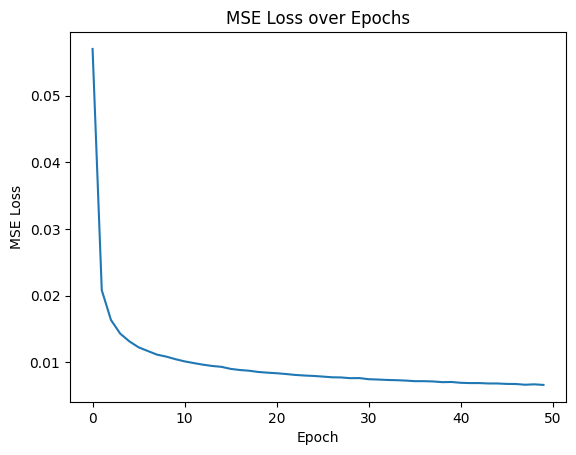

In [12]:
param_grid_autoencoder = {
    'learning_rate': [1e-3, 1e-4],
    'batch_size': [32, 64],
}

best_params_autoencoder, best_loss_autoencoder = find_best_param_autoencoder(param_grid_autoencoder)
print(f"Best parameters for Autoencoder: {best_params_autoencoder} with loss: {best_loss_autoencoder}")


# Training the final Autoencoder model with the best hyperparameters
autoencoder_best_model = AutoEncoderDecoder(input_shape=(32, 32, 1))
autoencoder_best_model.build_mode()
autoencoder_best_model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params_autoencoder['learning_rate']), loss='mse')

train_generator = datagenerator(mnist_x_train, fashion_mnist_x_train, best_params_autoencoder['batch_size'])
autoencoder_history = autoencoder_best_model.train(train_generator, epochs=epochs, steps_per_epoch=steps_per_epoch)
autoencoder_best_model.show_loss_epoch()
# print(autoencoder_best_model.summary())

<a name='evaluation'></a>
# Model evaluation

Let us define the test generator.

In this section we will take a look at the performance of the different models on the test data and their correesponding outputs.

In [13]:
testgen = datagenerator(mnist_x_test, fashion_mnist_x_test, 1000)
test_sample = datagenerator(mnist_x_test, fashion_mnist_x_test, 1)

Folowing cell show the evaluation of the model on the test set defined above.

In [14]:
repeat_eval = 10
eval_results_UNet = []
eval_results_AutoEnDe = []

for i in range(repeat_eval):
    UNet_mse = UNet_best_model.eval_model(testgen)
    # Since the next() is defined inside the function, each time the data is new
    EnDe_mse = autoencoder_best_model.eval_model(testgen)

    eval_results_UNet.append(UNet_mse)
    eval_results_AutoEnDe.append(EnDe_mse)

print("UNet MSE = ", np.mean(eval_results_UNet))
print("UNet Standard Deviation = ", np.std(eval_results_UNet))
print()
print("Auto Encode Decode MSE = ", np.mean(eval_results_AutoEnDe))
print("Auto Encode Decode Standard Deviation = ", np.std(eval_results_AutoEnDe))

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
UNet MSE =  0.0008693626533825997
UNet Standard Deviation =  1.7363293829411217e-05

Auto Encode Decode MSE =  0.004871941879718285
Auto Encode Decode Standard Deviation =  0.00012367505354146118


Based on the output, the UNet model is performing better on unseen data in terms of both MSE and generalization and stability.
- UNet
    - It has a very good and low MSE meaning the prediction is closer to the real output
    - A low STD also proves that the model's performance is consistent across different running.
- AutoEncoderDecoder
    - Same applies for this architecture, however, compared to the UNet, it is weaker.

Anyways, based on the results, the UNet outperforms the Auto Encoder Decoder in our implementaion for image decompostion task.


Following printed lists shows the different losses for each model in each running of the evaluation on the test set (above).

In [15]:
print("UNet: \n", eval_results_UNet)
print("Auto: \n", eval_results_AutoEnDe)

UNet: 
 [0.000868186137425598, 0.0008558948467165815, 0.0008936267497092862, 0.000863063696568466, 0.0008924112694335042, 0.000896363895637313, 0.0008584299542909034, 0.0008577482808189759, 0.0008642920285319492, 0.0008436096746934202]
Auto: 
 [0.004853563553604079, 0.004718795393537355, 0.004778369996292607, 0.0047529305854606425, 0.005008024275087937, 0.004700977276826801, 0.004970551724806555, 0.004881186176073122, 0.005039440939378213, 0.005015578876115541]


#### Sample Image Generation
Next cell, shows a sample of data and corresponding image generation.
By running the following cell with `n_sample=2` four rows of images will be generated in which each two is one sample. Simply:
- The odd rows are the original data and the input to the models
- The even rows are the predicted/generated images of the input.
- Inputs on each odd-even row is the same for clearnece.  


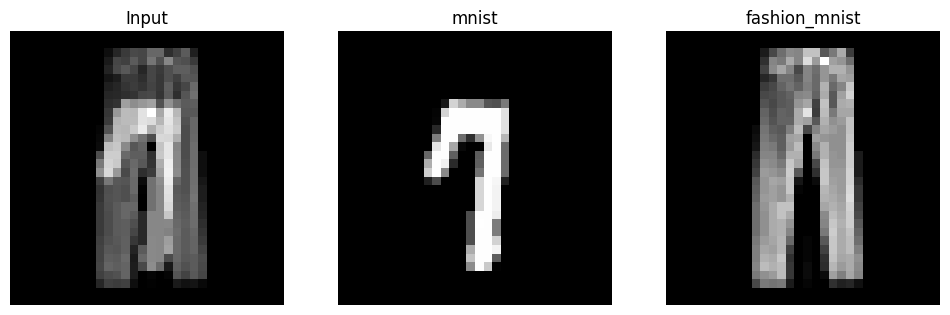

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


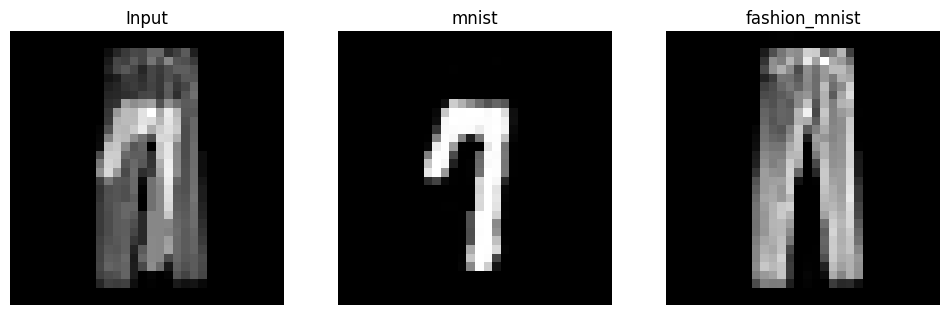

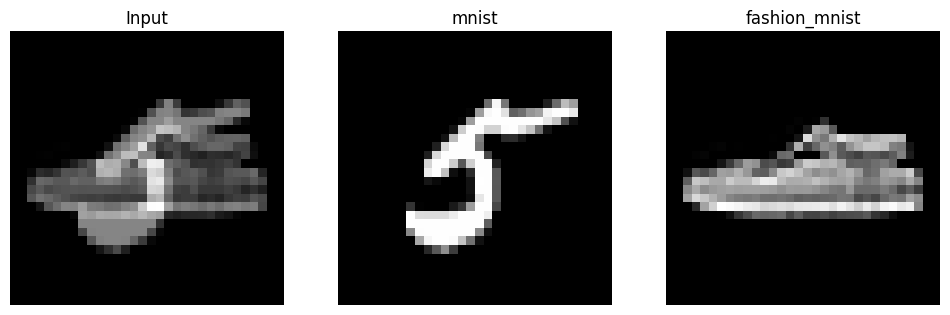

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


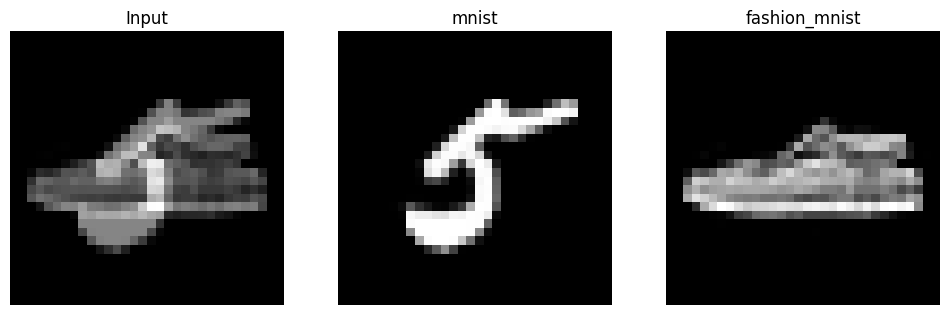

In [16]:
UNet_best_model.show_sample_prediction(test_sample, n_sample=2)

Similarly, the samples of image generated by the autoencoder is as follow:
- The odd rows are the original data and the input to the models.
- The even rows are the predicted/generated images of the input.
- Inputs on each odd-even row is the same for clearnece.  

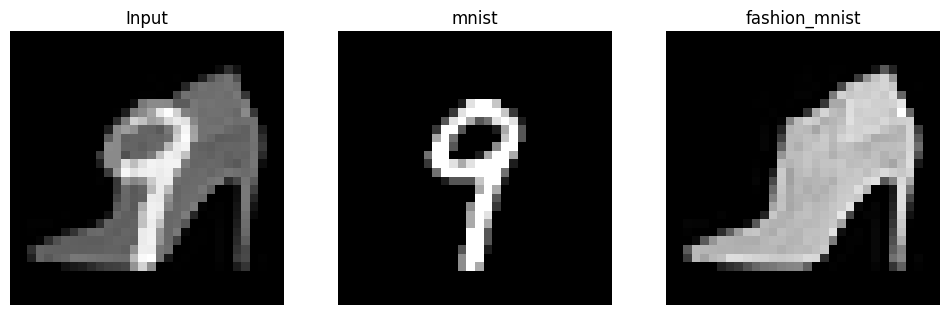

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step


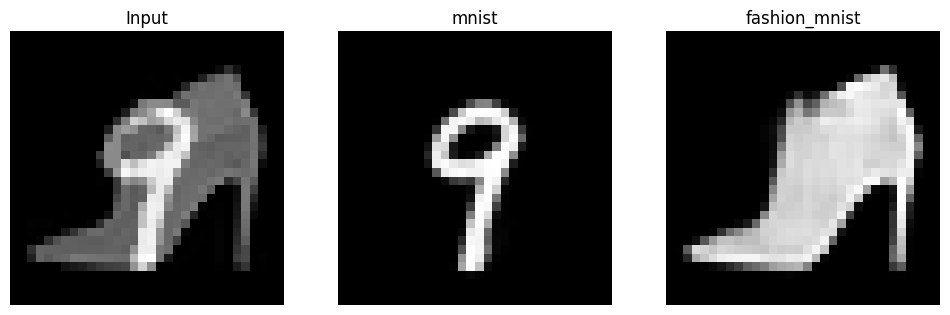

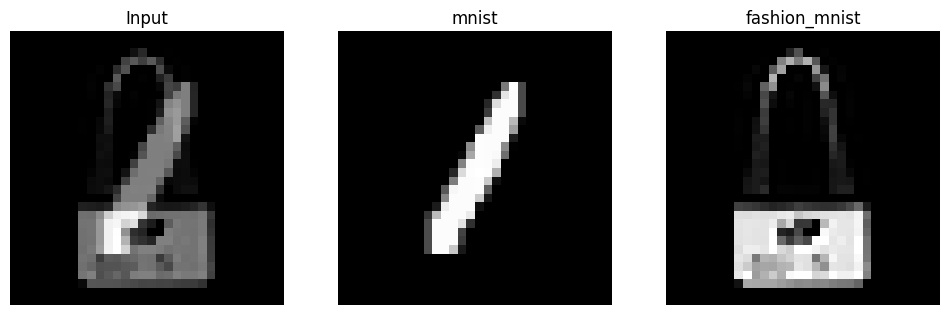

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


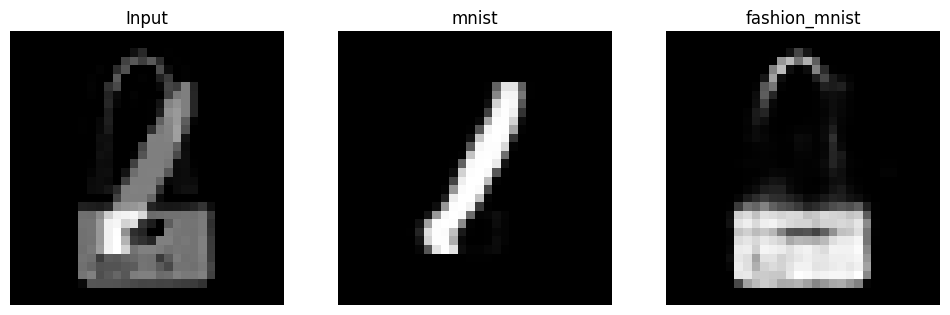

In [17]:
autoencoder_best_model.show_sample_prediction(test_sample, n_sample=2)

### MSE Curve
The following cell illustrates loss-epoch diagram:

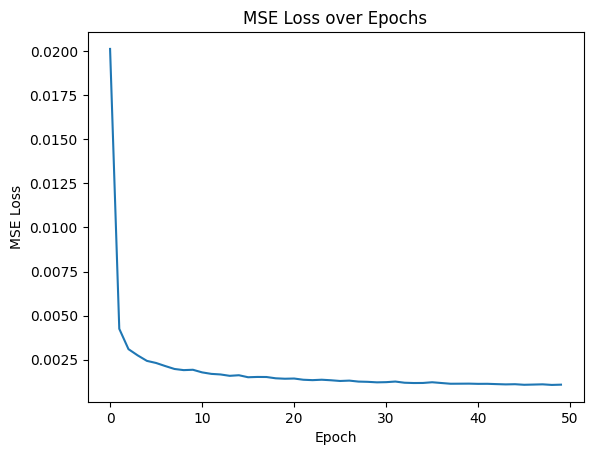

In [18]:
UNet_best_model.show_loss_epoch()

This illustraions shows a good and significant improvment and generation for of images with the UNet architecuture. The loss values didn't change significantly after epoch 10, which means that we could stop the trainin, as the result will not significantly change. Hence, it was better to also use other techniques such as `earlybird`, to stop the trainin when the loss is not changing easily. The follow code snippet could does this for us

In [19]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# UNet_best_model = UNet(input_shape=(32, 32, 1))
# UNet_best_model.build_model(n_ch=best_params['n_channel'], blocks=best_params['n_blocks'], conv_per_b=best_params['conv_per_block'])
# UNet_best_model.compile(optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']), loss='mse')

# train_generator = datagenerator(mnist_x_train, fashion_mnist_x_train, best_params['batch_size'])
# UNet_history = UNet_best_model.train(train_generator, epochs=epochs, steps_per_epoch=steps_per_epoch, callbacks=[early_stopping])


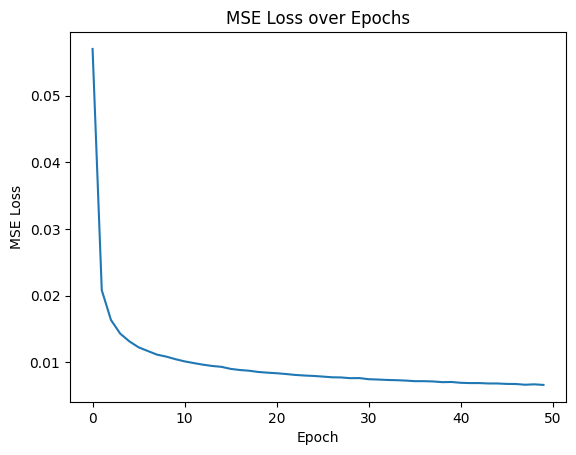

In [20]:
autoencoder_best_model.show_loss_epoch()

The illustration here also demonstrates a good curve of prediction of images. However, based on the values we can conclude that the model UNet is performing better in our task leading to a better results. The importance of stopping the training when the results are not getting better is understood completely by me and it could also be applied here to stop the trainig. Both models suggests that a good epochs number is around 10-15. The stopping training is an important role since, in real world problem, the resources are expensive.




One other thing that is not mentioned and cannot be seen is the training time. Training the UNet, in our case, took around 30 minutes with `A100 GPU` which is a lot compared to the 5 minutes of AutoEncoderDecoder. This is a clue that we might want to choose the Auto Encoder Decoder rather than the UNet in some applications. In other words, if the task that we want to use these models for is not a sensetive task, maybe it is better to use the AutoEncoderDecoder since it needs significantly less resources compared to the UNet and gives us a acceptable results.

Anyway, in different task, we should study the problem more in order to suggest a better model and a better model cannot always be the one with the best accuracy, since we have other metrics like resources and expenses to consider and think about.